# A Note About Multistage Compression

This note is not directly tied to the Ocelot codebase but addresses a recurring question in beam–dynamics modelling: **how to estimate the peak current after the final bunch compressor without running full particle tracking**.

We provide a simplified treatment that neglects velocity bunching and collective effects. These effects can significantly influence real machines, but understanding the underlying **kinematics of longitudinal compression** is essential before including such complications.

The formalism presented here is based on the approach developed in  
[I. Zagorodnov and M. Dohlus, *Semianalytical modeling of multistage bunch compression with collective effects*, PRSTAB 14, 014403 (2011)](https://journals.aps.org/prab/pdf/10.1103/PhysRevSTAB.14.014403).  
Their work provides a complete analytical framework including iterative algorithms for determining optimal compression settings.  
In this note, however, we focus on a simpler problem:

> **Given known RF parameters and known values of the bunch–compressor coefficients, estimate the peak current after the final stage while neglecting collective effects.**

A short reminder of basic compression theory is given below.  
Further introductory material is available in the Ocelot tutorial  
[*Accelerator–based THz source*](https://www.ocelot-collab.com/docs/tutorial/tutorial-beam-dynamics/thz_source).

---

## Linear Compression with a Chicane

A bunch compresses longitudinally when the tail travels a **shorter path length** (or experiences shorter time of flight) than the head.  
This requires a correlation between the longitudinal coordinate $s $ and the energy deviation $\delta $.

A linac producing a linear chirp
$$
\delta' = \frac{1}{E_0}\frac{dE}{ds}
$$
maps the beam as
$$
\begin{aligned}
s_1 &= s_0, \\
\delta_1 &= \delta' s_0 + \delta_i,
\end{aligned}
$$
where $ \delta_i = \Delta E_i / E_0 $ denotes uncorrelated energy spread.

Passing this beam through a chicane with longitudinal dispersion $ R_{56}$ gives
$$
\begin{aligned}
s_2 &= s_1 - R_{56}\,\delta_1 \\
    &= (1 - \delta' R_{56})\,s_0 - R_{56}\,\delta_i, \\
\delta_2 &= \delta_1.
\end{aligned}
$$
*(Signs depend on coordinate conventions. Usually $ R_{56} > 0 $ for a chicane means higher–energy particles arrive later.)*

Assuming $ \langle s_0 \delta_i \rangle = 0 $, the rms bunch length becomes
$$
\sigma_{s_2}
  = \sqrt{(1 - \delta' R_{56})^2\,\sigma_{s_0}^2 + R_{56}^2\,\sigma_{\delta_i}^2}.
$$

The compression factor is
$$
C = \frac{\sigma_{s_0}}{\sigma_{s_2}}.
$$

---

## Longitudinal Mapping in an RF System

Nonlinearities from RF fields and from magnetic compressors distort the longitudinal phase space.  
A harmonic RF system can be used to correct these distortions.

The RF voltage and phase of the fundamental and harmonic systems (with harmonic index $ n = 3 $ at EuXFEL) satisfy:
$$
\begin{bmatrix}
 1 & 0 & 1 & 0 \\
 0 & -k & 0 & -nk \\
 -k^2 & 0 & -(nk)^2 & 0 \\
 0 & k^3 & 0 & (nk)^3
\end{bmatrix}
\begin{bmatrix}
 V_1\cos\phi_{11} \\
 V_1\sin\phi_{11} \\
 V_{13}\cos\phi_{13} \\
 V_{13}\sin\phi_{13}
\end{bmatrix}
=
\frac{1}{e}
\begin{bmatrix}
 E_1 - E_0 \\
 E_1\delta_1'  - E_0\delta_0' \\
 E_1\delta_1'' - E_0\delta_0'' \\
 E_1\delta_1''' - E_0\delta_0'''
\end{bmatrix}.
$$

Given the incoming parameters $(E_0, \delta_0', \delta_0'', \delta_0''')$ and RF settings, one obtains the output parameters
$$
E_1,\qquad
\delta_1',\quad
\delta_1'',\quad
\delta_1'''.
$$

These become the input for the bunch compressor.

---

## Longitudinal Mapping in a Bunch Compressor

We expand the relative energy deviation around the bunch center:
$$
\delta(s)
=
 \delta'(0)\,s
+ \frac{\delta''(0)}{2}\,s^{2}
+ \frac{\delta'''(0)}{6}\,s^{3}.
$$

By definition of the reference particle,
$$
\delta(0) = 0,
$$
since all longitudinal transport coefficients $R_{56}, T_{566}, U_{5666}$ are defined with respect to the on–momentum particle.

### Mapping

Up to third order:
$$
s_2
=
s_1
-
\left[
  R_{56}\,\delta_1(s_1)
+ T_{566}\,\delta_1^2(s_1)
+ U_{5666}\,\delta_1^3(s_1)
\right],
\qquad
\delta_2(s_2) = \delta_1(s_1).
$$

### Jacobian

Differentiating the longitudinal map gives

$$
\frac{ds_2}{ds_1}
=
1 -
\left[
R_{56}
+ 2T_{566}\,\delta_1(s_1)
+ 3U_{5666}\,\delta_1^2(s_1)
\right]\delta_1'(s_1)
\equiv f'(s_1).
$$

At the bunch center, where $\delta_1(0)=0$,

$$
\left.\frac{ds_2}{ds_1}\right|_{s_1=0}
=
1 - R_{56}\,\delta_1'(0).
$$

Using the chain rule,

$$
\frac{d}{ds_2}
=
\frac{1}{f'(s_1)}\,\frac{d}{ds_1}.
$$

and since we only need derivatives **at the bunch center**, we evaluate all expressions at $s_1=0$.



#### First derivative (chirp)

$$
\delta_2'
=
\frac{\delta_1'}{1 - R_{56}\,\delta_1'}.
$$



#### Second derivative (curvature)

$$
\delta_2''
=
\frac{
       \delta_1'' + 2T_{566}(\delta_1')^3
     }
     {\left[1 - R_{56}\,\delta_1'\right]^3}.
$$



#### Third derivative (skew)

At the bunch center, the full expression is

$$
\delta_2''' =
\frac{
  \delta_1''' \left(1 - R_{56}\delta_1' \right)
  + 3R_{56}(\delta_1'')^{2}
  + 12T_{566}(\delta_1')^{2}\delta_1''
  + 6U_{5666}(\delta_1')^{4}\left(1 - R_{56}\delta_1'\right)
  + 12T_{566}^{2}(\delta_1')^{5}
     }
     {\left[1 - R_{56}\,\delta_1'\right]^{5}}.
$$



### Special Case: Pure $R_{56}$

Setting $T_{566} = U_{5666} = 0$:

$$
\delta_2'
=
\frac{\delta_1'}{1 - R_{56}\delta_1'},
$$

$$
\delta_2''
=
\frac{\delta_1''}{(1 - R_{56}\delta_1')^{3}},
$$

$$
\delta_2''' =
\frac{
  \delta_1'''(1 - R_{56}\delta_1')
 + 3R_{56}(\delta_1'')^{2}
     }
     {(1 - R_{56}\delta_1')^{5}}.
$$



## Tracking Derivatives Through Compression Stages

To estimate the final compression and the corresponding peak current after the last bunch compressor, we implemented three helper functions:

```python
E1, d1_1, d2_1, d3_1 = rf_longitudinal_map(
    v, phi, vh, phih,
    E0, d1, d2, d3,
    n=3, freq=1.3e9
)

d1_1, d2_1, d3_1, fprime = bc_longitudinal_map(
    d1, d2, d3,
    R56, T566, U5666
)

C, s1 = local_compression(
    s, d1, d2, d3,
    R56, T566=0, U5666=0
)

-0.04329847141021299 0.0655874080848681 -0.08852669738832675 4.821490630329327
-0.03078102261327647 0.04628624685194711 -0.061906661392198234 12.815361892614535
-0.018104041499916998 0.027186071229411784 -0.03629816541515801 16.80904452543293


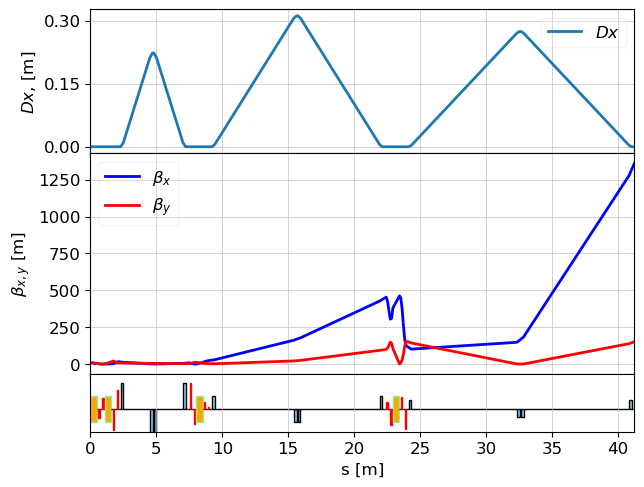

In [42]:
import sys
sys.path.append("/Users/tomins/Nextcloud/DESY/repository/ocelot")
from ocelot.utils.acc_utils import beam2rf, beam2rf_xfel_linac, rf_longitudinal_map, bc_longitudinal_map, local_compression
from ocelot.utils.acc_utils import chicane_RTU 
from ocelot import *
from ocelot.gui import *


def bc(L, R, yoke_len):
    alpha1 = yoke_len/R
    b1 = SBend(l=yoke_len, angle=alpha1, e2=alpha1, tilt=0, eid='B1')
    b2 = SBend(l=yoke_len, angle=-alpha1, e1=-alpha1, tilt=0, eid='B2')
    b3 = SBend(l=yoke_len, angle=-alpha1, e2=-alpha1, tilt=0, eid='B3')
    b4 = SBend(l=yoke_len, angle=alpha1, e1=alpha1, tilt=0, eid='B4')
    bc = [Drift(l=0.1), b1, Drift(l=L/np.cos(alpha1)), b2, d, b3, Drift(l=L/np.cos(alpha1)), b4, Drift(l=0.1)]
    return bc

# ---------------- BUNCH COMPRESSORS -----------------------------

yoke_len = 0.2
# BC1 
L1 = 2 # m BC shoulder in z projection
r1 = 2
r56_bc1, t566_bc1, u5666_bc1, Sref_bc1 = chicane_RTU(yoke_len=yoke_len, dip_dist=L1, r=r1, type="c")
print(r56_bc1, t566_bc1, u5666_bc1, Sref_bc1)
#BC2 
L2 = 6 # m BC shoulder in z projection
r2 = 4
r56_bc2, t566_bc2, u5666_bc2, Sref_bc2 = chicane_RTU(yoke_len=yoke_len, dip_dist=L2, r=r2, type="c")
print(r56_bc2, t566_bc2, u5666_bc2, Sref_bc2)

#BC3 
L3 = 8 # m BC shoulder in z projection
r3 = 6
r56_bc3, t566_bc3, u5666_bc3, Sref_bc3 = chicane_RTU(yoke_len=yoke_len, dip_dist=L3, r=r3, type="c")
print(r56_bc3, t566_bc3, u5666_bc3, Sref_bc3)
# ---------------- BUNCH COMPRESSORS -----------------------------

# ---------------- RF -----------------------------
# RF parameters 
E0 = 0.1 # GeV
E1 = 0.3   # GeV
E2 = 0.7   # GeV
E3 = 2     # GeV
chirp1 = -12.
chirp2 = -12.3
chirp3 = -13
v1, phi1, vh, phih = beam2rf(E1, chirp=chirp1, curvature=600, skewness=10000, n=3, freq=1.3e9, E0=E0)
v2, phi2 = beam2rf_xfel_linac(sum_voltage=E2 - E1, chirp=chirp2, init_energy=E1)
v3, phi3 = beam2rf_xfel_linac(sum_voltage=E3 - E2, chirp=chirp3, init_energy=E2)
# ---------------- RF -----------------------------

# ---------------- LATICE -----------------------------
d = Drift(l=0.1)
n = 3
c11 = Cavity(l=0.5, v=v1, phi=phi1, freq=1.3e9)
c13 = Cavity(l=0.5, v=vh, phi=phih, freq=1.3e9 * n)
c21 = Cavity(l=0.5, v=v2, phi=phi2, freq=1.3e9)
c31 = Cavity(l=0.5, v=v3, phi=phi3, freq=1.3e9)
q = lambda k: Quadrupole(l=0.1, k1=k)
# ---------------- LATICE -----------------------------


stage1 = [ c11, d, q(-12), d,d, q(13), d,  c13,d, q(-27), d,d, q(23), d, bc(L1, R=r1, yoke_len=yoke_len), d]
stage2 = [  d, q(32), d,d, q(-19), d,  c21,d, q(8), d,d, q(2), d, bc(L2, R=r2, yoke_len=yoke_len), d]
stage3 = [  d, q(8), d,d, q(-20), d,  c31,d, q(14), d,d, q(-25), d, bc(L3, R=r3, yoke_len=yoke_len), d]

lat = MagneticLattice(stage1 + stage2 + stage3, method={"global":SecondTM})

tws0 = Twiss(beta_x=10, beta_y=10, alpha_x=-2, alpha_y=-2, emit_xn=1e-6, emit_yn=1e-6, E=E0)

tws = twiss(lat, tws0)
plot_opt_func(lat, tws, legend=False)

[INFO    ] Using Twiss parameters — overriding sigma_{x,px,y,py} values.


z = 41.2439923204789 / 41.24399232047892. Applied:   

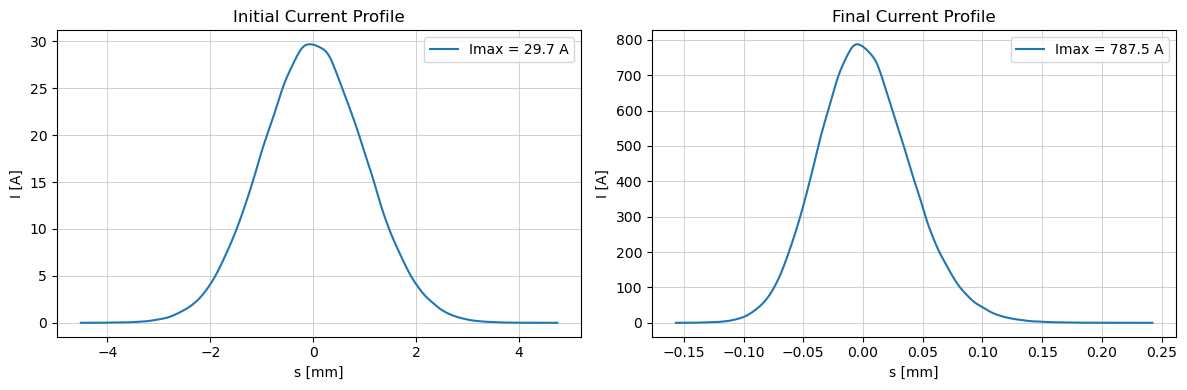

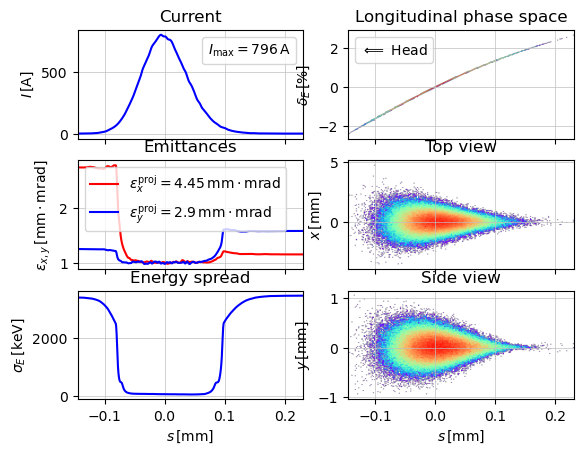

In [43]:
p_array = generate_parray(tws=tws0, charge=250e-12, sigma_tau=1e-3, chirp=0, sigma_p=1e-6)
I_init = p_array.I()
I_init_max = I_init[:, 1].max()
_, _ = track(lat, p_array)
#show_e_beam(p_array)
I_end = p_array.I()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left subplot: initial current ---
axes[0].plot(I_init[:, 0]*1e3, I_init[:, 1], label=f"Imax = {np.round(I_init_max, 1)} A")
axes[0].set_title("Initial Current Profile")
axes[0].set_xlabel("s [mm]")
axes[0].set_ylabel("I [A]")
axes[0].grid(True)
axes[0].legend()
# --- Right subplot: final current ---
axes[1].plot(I_end[:, 0]*1e3, I_end[:, 1], label=f"Imax = {np.round(I_end[:, 1].max(), 1)} A")
axes[1].set_title("Final Current Profile")
axes[1].set_xlabel("s [mm]")
axes[1].set_ylabel("I [A]")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()

plt.show()
show_e_beam(p_array)

AFTER INJECTOR
E1 = 0.30000000000000004, delta' = -11.999999999999996, delta'' = 599.9999999999998, delta''' = 9999.999999999973

compression C1 =  2.0815191892845735
AFTER L1
E2 = 0.7, delta' = -23.004955830606374, delta'' = 1018.7734725191696, delta''' = 141539.65219759615

Compression C2 =  3.426019325764971
AFTER L2
E3 = 1.9999999999999998, delta' = -40.58539814240945, delta'' = -2006.5864109088739, delta''' = 8092107.696088413

compression C3 =  3.7701666060124457
798.0024747797622


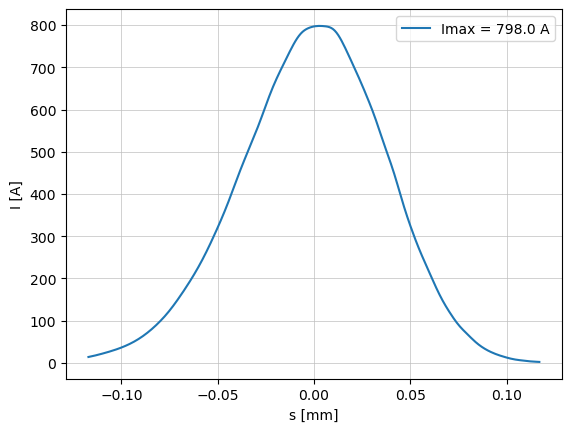

In [44]:
# First stage - Injector
E1, delta1_1, delta1_2, delta1_3  = rf_longitudinal_map(v=v1, phi= phi1, vh=vh, phih=phih, E0=E0)
print("AFTER INJECTOR")
print(f"E1 = {E1}, delta' = {delta1_1}, delta'' = {delta1_2}, delta''' = {delta1_3}")
print()

delta2_1, delta2_2, delta2_3, fp = bc_longitudinal_map(delta1_1, delta1_2,  delta1_3, R56=r56_bc1, T566=t566_bc1, U5666=u5666_bc1)

s, I = I_init[70:-50, 0], I_init[70:-50, 1]
C1_s, s2 = local_compression(s, delta1_1, delta1_2,  delta1_3, R56=r56_bc1, T566=t566_bc1, U5666=u5666_bc1)

C1 = 1/fp
print("compression C1 = ", C1)

# Second stage
E2, delta3_1, delta3_2, delta3_3  = rf_longitudinal_map(v=v2, phi= phi2, vh=0, phih=0, E0=E1, delta1=delta2_1, delta2=delta2_2, delta3=delta2_3)
print("AFTER L1")
print(f"E2 = {E2}, delta' = {delta3_1}, delta'' = {delta3_2}, delta''' = {delta3_3}")
print()

delta4_1, delta4_2, delta4_3, fp3 = bc_longitudinal_map(delta3_1, delta3_2, delta3_3, R56=r56_bc2, T566=t566_bc2, U5666=u5666_bc2)
C2 = 1/fp3
C2_s, s3 = local_compression(s2, delta3_1, delta3_2, delta3_3, R56=r56_bc2, T566=t566_bc2, U5666=u5666_bc2)

print("Compression C2 = ", C2)

# Third stage
E3, delta5_1, delta5_2, delta5_3  = rf_longitudinal_map(v=v3, phi= phi3, vh=0, phih=0, E0=E2, delta1=delta4_1, delta2=delta4_2, delta3=delta4_3)
print("AFTER L2")
print(f"E3 = {E3}, delta' = {delta5_1}, delta'' = {delta5_2}, delta''' = {delta5_3}")
print()

delta6_1, delta6_2, delta6_3, fp4 = bc_longitudinal_map(delta5_1, delta5_2, delta5_3, R56=r56_bc3, T566=t566_bc3, U5666=u5666_bc3)
C3 = 1/fp4
C3_s, s4 = local_compression(s3, delta5_1, delta5_2, delta5_3, R56=r56_bc3, T566=t566_bc3, U5666=u5666_bc3)
#print(C3_s)
print("compression C3 = ", C3)
print(C1*C2*C3 * I_init_max)

plt.plot(s4 * 1e3, C1_s * C2_s*C3_s * I, label=f"Imax = {np.round(max(C1_s * C2_s*C3_s * I), 1)} A")
plt.xlabel("s [mm]")
plt.ylabel("I [A]")
plt.legend()
plt.show()

## The EuXFEL case 

In [4]:
def final_compression(s, I, v1, phi1, vh, phih, v2, phi2, v3, phi3, E0):
    # I got them from our usual compression setup in ocelot. 
    # LH 
    R56_lh = -0.00471539762792759; T566_lh = 0.007109202460937953 ; 
    # DL 
    R56_dl = -0.030014734457023805; T566_dl = 0.09739278402348064 
    # BC0
    R56_bc0 = -0.040121443393344905; T566_bc0 = 0.060991121039115484 
    # BC1
    R56_bc1 = -0.06303412031337753; T566_bc1 = 0.0948828477178126 
    # BC2
    R56_bc2 = -0.021305525353687016; T566_bc2 = 0.0319962244281959 
    
    r56_bc0 = R56_lh + R56_dl + R56_bc0; t566_bc0 = T566_lh + T566_dl + T566_bc0 
    u5666_bc0 = 0
    u5666_bc1 = 0
    u5666_bc2 = 0

    # first stage 
    E1, delta1_1, delta1_2, delta1_3  = rf_longitudinal_map(v=v1, phi= phi1, vh=vh, phih=phih, E0=E0)
    
    delta2_1, delta2_2, delta2_3, fp = bc_longitudinal_map(delta1_1, delta1_2,  delta1_3, R56=r56_bc0, T566=t566_bc0, U5666=u5666_bc0)
    
    C1_s, s2 = local_compression(s, delta1_1, delta1_2,  delta1_3, R56=r56_bc0, T566=t566_bc0, U5666=u5666_bc0)

    # second stage
    E2, delta3_1, delta3_2, delta3_3  = rf_longitudinal_map(v=v2, phi= phi2, vh=0, phih=0, E0=E1, delta1=delta2_1, delta2=delta2_2, delta3=delta2_3)
   
    delta4_1, delta4_2, delta4_3, fp3 = bc_longitudinal_map(delta3_1, delta3_2, delta3_3, R56=R56_bc1, T566=T566_bc1, U5666=u5666_bc1)
    C2 = 1/fp3
    C2_s, s3 = local_compression(s2, delta3_1, delta3_2, delta3_3, R56=r56_bc1, T566=t566_bc1, U5666=u5666_bc1)

    # Third stage
    E3, delta5_1, delta5_2, delta5_3  = rf_longitudinal_map(v=v3, phi= phi3, vh=0, phih=0, E0=E2, delta1=delta4_1, delta2=delta4_2, delta3=delta4_3)
    
    delta6_1, delta6_2, delta6_3, fp4 = bc_longitudinal_map(delta5_1, delta5_2, delta5_3, R56=r56_bc2, T566=t566_bc2, U5666=u5666_bc2)
    C3 = 1/fp4
    C3_s, s4 = local_compression(s3, delta5_1, delta5_2, delta5_3, R56=r56_bc2, T566=t566_bc2, U5666=u5666_bc2)

    
    return s4, C1_s * C2_s * C3_s * I
    